# Proyecto: Predicción de diabetes

**Integrantes:**
-  Hilter Piero Lanche Cerron
-  Jorge Andres Chavarri Centeno
-  Joel Joseph Rivera Matias

# 📌 Fase 1. Business Understanding

## 🎯 1. Objetivo

El objetivo de este proyecto es desarrollar un **modelo predictivo** que permita predecir si una persona tendra **diabetes** (variable QS109) a partir de características sociodemográficas, clínicas y de estilo de vida, específicamente:  

- **Edad de la persona** (QS23)
- **Sexo** (QS14)
- **Mediciones antropométricas**: peso (QS900), talla (QS901), perímetro abdominal (QS907).
- **Presión arterial**: sistólica y diastólica (QS903S, QS903D, QS905S, QS905D), y diagnóstico de hipertensión (QS102).
- **Estilo de vida**: consumo de tabaco (QS200–QS205) y alcohol (QS206–QS210).
- **Dieta**: frecuencia de consumo de frutas, verduras y jugos (QS213C–QS220CV).

**Metricas tecnicas:**
- Exactitud (Accuracy)	≥ 0.70	≥ 0.80	Un modelo de salud debe ser consistente en su prediccion
- Precisión (Precision)	≥ 0.65	≥ 0.75	Evita falsos positivos innecesarios (personas sanas marcadas como diabéticas).
- AUC-ROC	≥ 0.75	≥ 0.85	Capacidad de discriminar entre personas con y sin diabetes.

**Metricas de negocio:**

- Capacidad del modelo para identificar individuos en riesgo usando solo variables sociodemográficas, clínicas básicas y de estilo de vida, sin exámenes de laboratorio.
- Reducción de costos: potencial de disminuir gastos en pruebas médicas invasivas al focalizar recursos en quienes tienen mayor probabilidad de diabetes.
- Prevención y detección temprana: contribuir a que los sistemas de salud puedan diseñar programas preventivos dirigidos a los grupos de mayor riesgo.


# 📌 Fase 2. Data Understanding

## 📥 2. Data collection

In [1]:
import pandas as pd
import numpy as np


data = pd.read_csv("CSALUD01_2024.csv",
                   low_memory=False ,
                    encoding='utf-8',      # o 'latin-1' si hay caracteres especiales
                    sep=',',               # separador (por defecto es coma)
                    header=0,              # fila que contiene los nombres de columnas
                    index_col=None)        # si quieres usar una columna como índice

In [2]:
# Resumen general
data.info()
print('data.columns:',data.columns)
print('data.shape:',data.shape)
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31484 entries, 0 to 31483
Columns: 258 entries, ID1 to PESO15_AMAS
dtypes: float64(226), int64(28), object(4)
memory usage: 62.0+ MB
data.columns: Index(['ID1', 'HHID', 'QHCLUSTER', 'QHNUMBER', 'QHHOME', 'QSNUMERO', 'QSINTM',
       'QSINTY', 'QSTOTVISIT', 'QSRESULT',
       ...
       'QS731_E', 'QS731_EA', 'QS731_F', 'QS731_G', 'QS731_H', 'QS731_I',
       'QS731_J', 'QS731_X', 'QS731_Y', 'PESO15_AMAS'],
      dtype='object', length=258)
data.shape: (31484, 258)


,ID1,HHID,QHCLUSTER,QHNUMBER,QHHOME,QSNUMERO,QSINTM,QSINTY,QSTOTVISIT,QSRESULT,...,QS731_E,QS731_EA,QS731_F,QS731_G,QS731_H,QS731_I,QS731_J,QS731_X,QS731_Y,PESO15_AMAS
0,2024,325503101,3255,31,1,2,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,157182.172078
1,2024,325503901,3255,39,1,2,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200845.215117
2,2024,325504001,3255,40,1,1,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,432165.467954
3,2024,325504701,3255,47,1,1,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162338.353517
4,2024,325505001,3255,50,1,2,5,2024,2,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162338.353517
5,2024,325505301,3255,53,1,1,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122249.475108
6,2024,325508901,3255,89,1,2,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,122249.475108
7,2024,325509301,3255,93,1,2,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,200845.215117
8,2024,325509701,3255,97,1,1,5,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,213186.731519
9,2024,325600601,3256,6,1,1,6,2024,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135655.313927


El **data frame** contenía **259 variables**, correspondientes a una encuesta amplia. Sin embargo, para iniciar el análisis descriptivo y facilitar la interpretación de resultados y la visualizacion de los graficos estadisticos, se redujo a **29 variables** seleccionadas, priorizando aquellas de mayor relevancia temática en relación con el estudio

In [3]:
# Crear nuevo dataframe con solo las columnas seleccionadas
data = data[['QSSEXO', 'QS23', 'QS102', 'QS109', 'QS202', 'QS203C',
              'QS205C', 'QS206', 'QS207C', 'QS208', 'QS209','QS210', 
              'QS212A','QS212G', 'QS211C', 'QS213C',
              'QS218C', 'QS219C', 'QS200', 'QS201', 'QS304', 'QS500',
              'QS900', 'QS901', 'QS903S', 'QS903D', 'QS905S', 'QS905D',
              'QS907']]


In [4]:
# Resumen general
data.info()
print('data.columns:',data.columns)
print('data.shape:',data.shape)
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31484 entries, 0 to 31483
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   QSSEXO  31484 non-null  int64  
 1   QS23    31484 non-null  int64  
 2   QS102   31481 non-null  float64
 3   QS109   31481 non-null  float64
 4   QS202   2896 non-null   float64
 5   QS203C  356 non-null    float64
 6   QS205C  356 non-null    float64
 7   QS206   31467 non-null  float64
 8   QS207C  28525 non-null  float64
 9   QS208   28886 non-null  float64
 10  QS209   21129 non-null  float64
 11  QS210   21129 non-null  float64
 12  QS212A  10312 non-null  float64
 13  QS212G  10312 non-null  float64
 14  QS211C  10312 non-null  float64
 15  QS213C  28434 non-null  float64
 16  QS218C  5415 non-null   float64
 17  QS219C  22778 non-null  float64
 18  QS200   31467 non-null  float64
 19  QS201   4929 non-null   float64
 20  QS304   8186 non-null   float64
 21  QS500   31457 non-null  float64
 22

,QSSEXO,QS23,QS102,QS109,QS202,QS203C,QS205C,QS206,QS207C,QS208,...,QS201,QS304,QS500,QS900,QS901,QS903S,QS903D,QS905S,QS905D,QS907
0,2,38,2.0,2.0,NaN,NaN,NaN,1.0,17.0,2.0,...,NaN,NaN,1.0,70.4,152.5,126.0,93.0,123.0,95.0,98.9
1,2,17,2.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,2.0,49.8,160.2,86.0,68.0,90.0,65.0,68.4
2,2,65,2.0,2.0,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,2.0,2.0,49.7,136.2,123.0,79.0,121.0,74.0,86.3
3,1,33,2.0,2.0,2.0,NaN,NaN,1.0,17.0,1.0,...,1.0,NaN,2.0,76.0,158.2,123.0,89.0,118.0,87.0,100.4
4,1,30,2.0,2.0,NaN,NaN,NaN,1.0,21.0,2.0,...,NaN,NaN,2.0,66.0,159.4,107.0,70.0,119.0,72.0,87.2
5,2,32,2.0,2.0,NaN,NaN,NaN,1.0,18.0,1.0,...,NaN,NaN,2.0,72.9,157.0,128.0,88.0,126.0,86.0,91.7
6,2,34,2.0,2.0,NaN,NaN,NaN,1.0,26.0,2.0,...,NaN,NaN,2.0,57.3,153.3,90.0,56.0,96.0,65.0,80.2
7,2,18,2.0,2.0,NaN,NaN,NaN,1.0,17.0,1.0,...,NaN,NaN,2.0,67.6,151.5,105.0,75.0,108.0,74.0,93.2
8,1,45,2.0,2.0,NaN,NaN,NaN,1.0,19.0,1.0,...,NaN,NaN,2.0,85.7,171.6,133.0,88.0,134.0,87.0,101.1
9,2,33,2.0,2.0,NaN,NaN,NaN,1.0,24.0,1.0,...,NaN,NaN,2.0,81.2,158.3,109.0,75.0,108.0,75.0,108.1


## 📊 3. Descriptive analysis

### 3.1 Análisis descriptivo

In [5]:
#Resumen estadístico de todas las variables (describe()).
data.describe(include="all").T 

,count,mean,std,min,25%,50%,75%,max
QSSEXO,31484.0,1.579247,0.493688,1.0,1.0,2.0,2.0,2.0
QS23,31484.0,39.886387,16.973088,15.0,27.0,36.0,50.0,97.0
QS102,31481.0,1.917220,0.320334,1.0,2.0,2.0,2.0,8.0
QS109,31481.0,1.969092,0.254248,1.0,2.0,2.0,2.0,8.0
QS202,2896.0,1.876727,0.328808,1.0,2.0,2.0,2.0,2.0
QS203C,356.0,25.671348,11.532263,10.0,18.0,21.0,30.0,78.0
QS205C,356.0,4.303371,4.003251,1.0,2.0,3.0,5.0,20.0
QS206,31467.0,1.082785,0.285085,1.0,1.0,1.0,1.0,8.0
QS207C,28525.0,19.123050,4.876925,5.0,16.0,18.0,20.0,68.0
QS208,28886.0,1.269785,0.453577,1.0,1.0,1.0,2.0,8.0


In [6]:
# Separar los datos segú sus Tipos de variables (numéricas, categóricas). fechas se considera como cat aunque también puedes separr
#numeric_data = data.select_dtypes(include=[np.number])
#categor_data = data.select_dtypes(exclude=[np.number])
#print ("Hay {} variables númericas y {} categóricas en la data".format(numeric_data.shape[1],categor_data.shape[1]))

In [7]:
# Puedes ver la Distribución de variables numéricas
# data.describe().T

In [8]:
#Variables únicas en cada variable
#categor_data.describe(include="all").T

In [9]:
from IPython.display import Markdown, display

# Diccionario de etiquetas (Código → Descripción)
labels = {
    'QSSEXO': "SEXO",
    'QS23': "EDAD",
    'QS102': "Le diagnosticaron Hipertensión Arterial o Presión Alta",
    'QS202': "Fuma diariamente",
    'QS207C': "Edad que empezó a fumar diariamente",
    'QS209': "En los últimos 12 meses ha consumido alguna bebida alcohólica",
    'QS219C': "Días que comió ensalada de verduras",
    'QS900': "Peso (kg) - Personas de 15 años a más",
    'QS901': "Talla (cm) - Personas de 15 años a más",
    'QS907': "Perímetro abdominal (cm)",
    'QS206' : "asda",
    'QS905S': "Segunda medición presión arterial diastólica",
    'QS905D': "Segunda medición presión arterial sistólica"
}

# Conteo de valores únicos con etiqueta arriba
for col in labels.keys():
    display(Markdown(f"\n##### {col} → {labels[col]}"))
    print(data[col].value_counts())



# Conteo de la variable objetivo
display(Markdown("\n\n### QS109 → Le diagnosticaron diabetes"))
data["QS109"].value_counts()



##### QSSEXO → SEXO

QSSEXO
2    18237
1    13247
Name: count, dtype: int64



##### QS23 → EDAD

QS23
32    976
31    967
36    942
29    930
30    918
     ... 
94     12
97      9
96      9
93      6
95      4
Name: count, Length: 83, dtype: int64



##### QS102 → Le diagnosticaron Hipertensión Arterial o Presión Alta

...

QS905S
110.0    875
105.0    847
108.0    843
107.0    837
115.0    837
        ... 
63.0       1
70.0       1
65.0       1
210.0      1
219.0      1
Name: count, Length: 146, dtype: int64



##### QS905D → Segunda medición presión arterial sistólica

QS905D
72.0     1329
70.0     1322
75.0     1249
71.0     1247
76.0     1230
         ... 
130.0       1
124.0       1
131.0       1
126.0       1
123.0       1
Name: count, Length: 95, dtype: int64




### QS109 → Le diagnosticaron diabetes

QS109
2.0    30326
1.0     1129
8.0       26
Name: count, dtype: int64

### 3.2 Análisis descriptivo (gráficos)

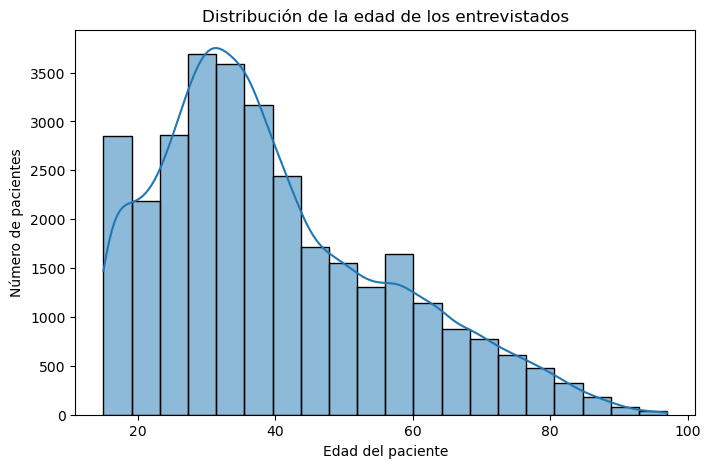

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de la edad de los pacientes
plt.figure(figsize=(8,5))
sns.histplot(data['QS23'], bins=20, kde=True)
plt.title("Distribución de la edad de los entrevistados")
plt.xlabel("Edad del paciente")
plt.ylabel("Número de pacientes")
plt.show()

👉 El gráfico muestra que la mayoría de los entrevistados se concentra en edades jóvenes y adultas jóvenes, principalmente entre los 20 y 40 años, mientras que a partir de los 50 años la frecuencia comienza a disminuir de forma progresiva y en los 70 años o más los casos son poco representativos. Esto indica que la muestra está compuesta mayoritariamente por población en edad productiva, con menor proporción de adultos mayores.

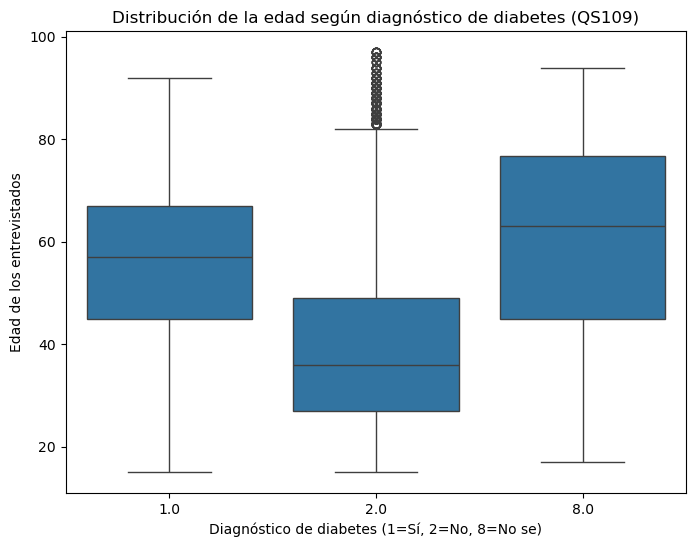

In [11]:
# Relación entre Edad y Diagnostico de Diabetes
plt.figure(figsize=(8,6))  # tamaño más compacto que con 18
sns.boxplot(x="QS109", y="QS23", data=data)  # QS109 = sí/no, QS23 = edad
plt.xlabel("Diagnóstico de diabetes (1=Sí, 2=No, 8=No se)")
plt.ylabel("Edad de los entrevistados")
plt.title("Distribución de la edad según diagnóstico de diabetes (QS109)")
plt.show()

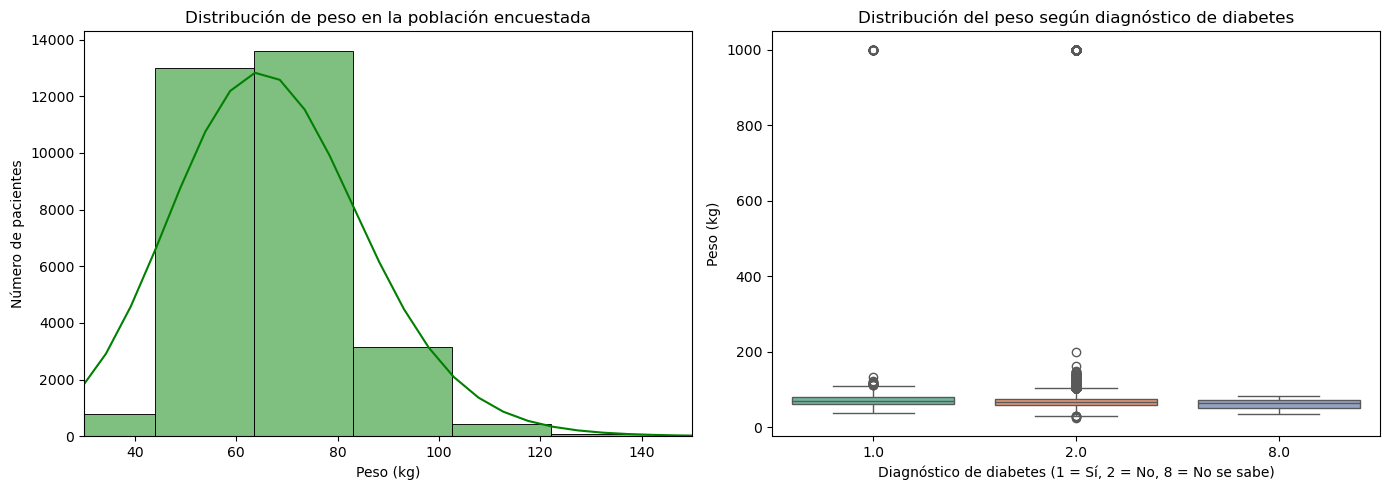

In [12]:
# Distribución del peso (histograma general)
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)  # lado izquierdo
sns.histplot(data['QS900'], bins=50, kde=True, color="green")
plt.xlim(30, 150)
plt.xlabel("Peso (kg)")
plt.ylabel("Número de pacientes")
plt.title("Distribución de peso en la población encuestada")

# Comparación del peso según diabetes (boxplot)
plt.subplot(1,2,2)  # lado derecho
sns.boxplot(y='QS900', x='QS109', hue='QS109', data=data, palette="Set2", legend=False)
plt.xlabel("Diagnóstico de diabetes (1 = Sí, 2 = No, 8 = No se sabe)")
plt.ylabel("Peso (kg)")
plt.title("Distribución del peso según diagnóstico de diabetes")

plt.tight_layout()
plt.show()


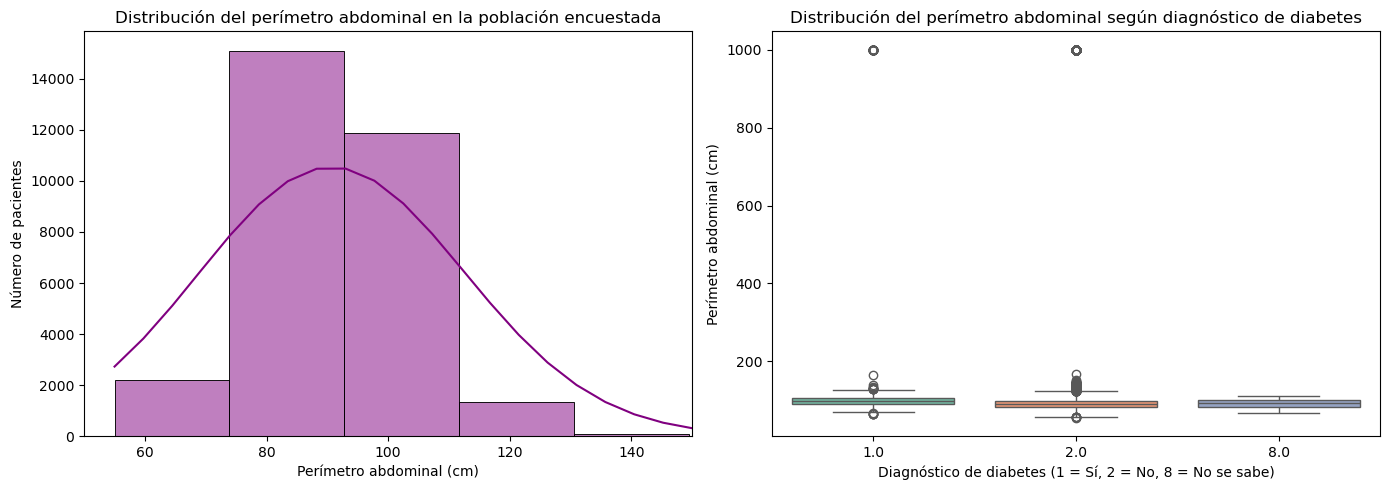

In [13]:
plt.figure(figsize=(14,5))

# Histograma
plt.subplot(1,2,1)
sns.histplot(data['QS907'], bins=50, kde=True, color="purple")
plt.xlim(50, 150)  # rango típico en cm
plt.xlabel("Perímetro abdominal (cm)")
plt.ylabel("Número de pacientes")
plt.title("Distribución del perímetro abdominal en la población encuestada")

# Boxplot según diabetes
plt.subplot(1,2,2)
sns.boxplot(x='QS109', y='QS907', hue='QS109', data=data, palette="Set2", legend=False)
plt.xlabel("Diagnóstico de diabetes (1 = Sí, 2 = No, 8 = No se sabe)")
plt.ylabel("Perímetro abdominal (cm)")
plt.title("Distribución del perímetro abdominal según diagnóstico de diabetes")

plt.tight_layout()
plt.show()

/tmp/ipykernel_5948/3511522870.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='QS206', data=diabeticos, palette="Set2")


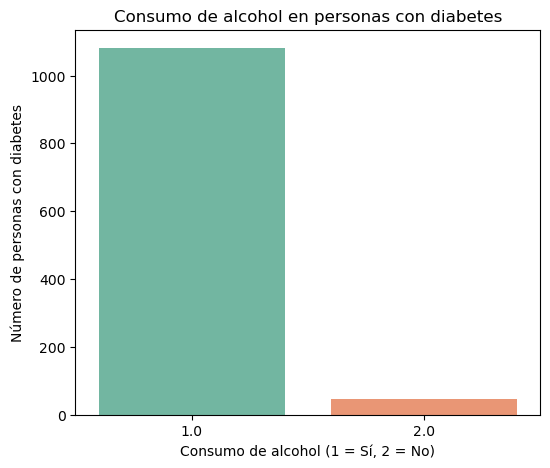

In [14]:
# Filtrar solo personas con diabetes (QS109 = 1)
diabeticos = data[data['QS109'] == 1]

plt.figure(figsize=(6,5))
sns.countplot(x='QS206', data=diabeticos, palette="Set2")
plt.xlabel("Consumo de alcohol (1 = Sí, 2 = No)")
plt.ylabel("Número de personas con diabetes")
plt.title("Consumo de alcohol en personas con diabetes")
plt.show()

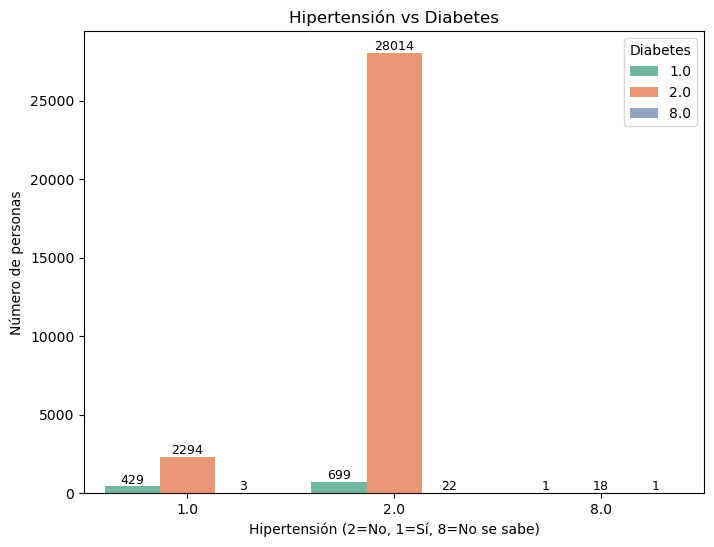

In [15]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x='QS102', hue='QS109', data=data, palette='Set2')

plt.title("Hipertensión vs Diabetes")
plt.xlabel("Hipertensión (2=No, 1=Sí, 8=No se sabe)")
plt.ylabel("Número de personas")
plt.legend(title="Diabetes")

# Agregar los valores en cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

plt.show()

### 3.3 Análisis exploratorio (con estadísticas): Correlaciones y cruces de variables

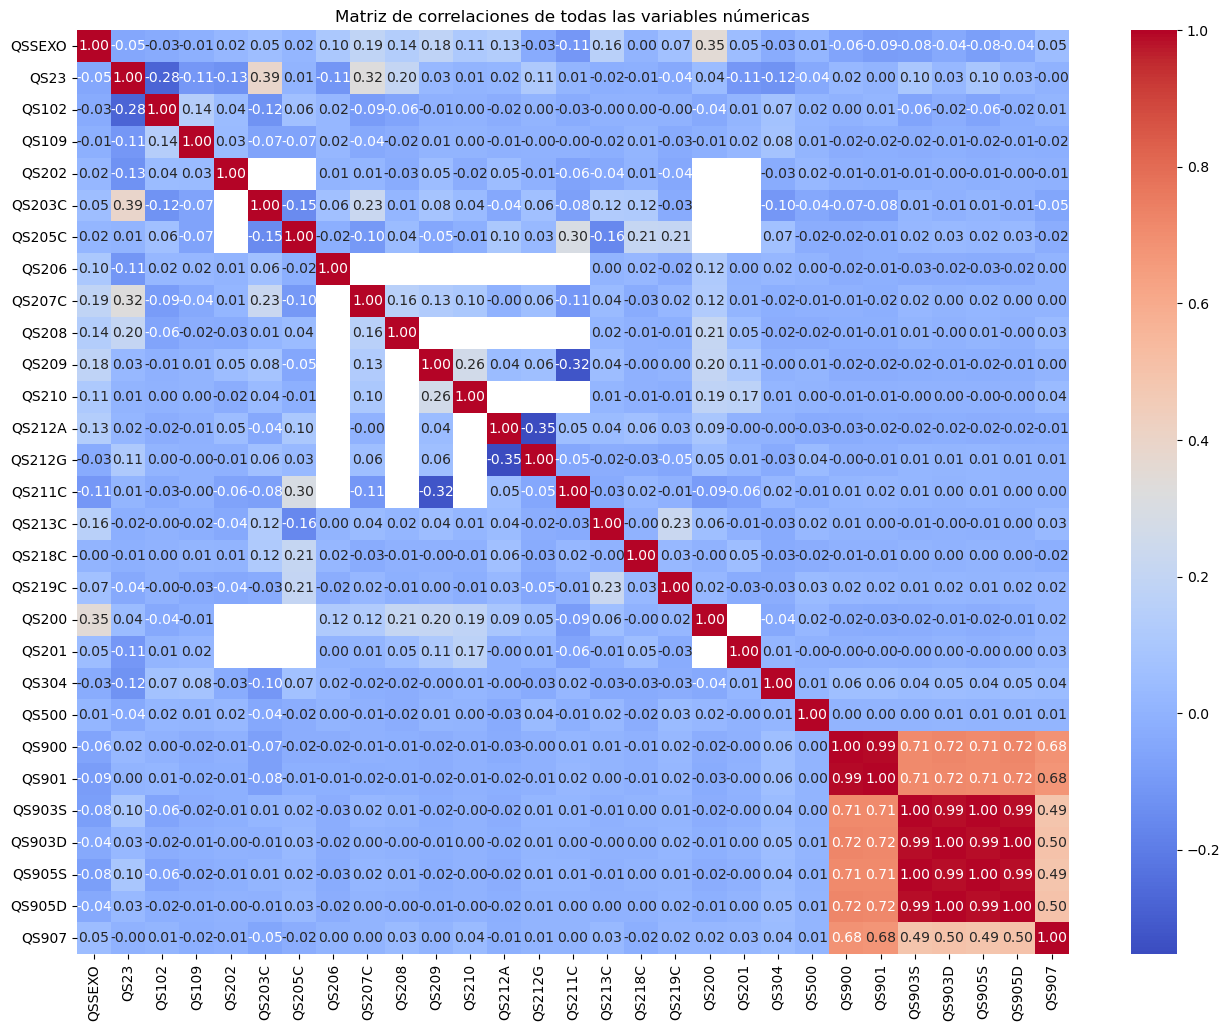

QSSEXO,1,2
QS109,,
1.0,37.732507,62.267493
2.0,42.240981,57.759019
8.0,38.461538,61.538462


In [16]:
# Correlaciones de todas las variables númericas
plt.figure(figsize=(16,12))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlaciones de todas las variables númericas")
plt.show()

# Cruce de variables categóricas con el objetivo
pd.crosstab(data['QS109'], data['QSSEXO'], normalize='index') * 100

### 3.4 Diagnóstico de calidad inicial

In [17]:
# Valores faltantes
print(data.isnull().sum())

QSSEXO        0
QS23          0
QS102         3
QS109         3
QS202     28588
QS203C    31128
QS205C    31128
QS206        17
QS207C     2959
QS208      2598
QS209     10355
QS210     10355
QS212A    21172
QS212G    21172
QS211C    21172
QS213C     3050
QS218C    26069
QS219C     8706
QS200        17
QS201     26555
QS304     23298
QS500        27
QS900        35
QS901        35
QS903S       33
QS903D       33
QS905S       33
QS905D       33
QS907        33
dtype: int64


In [18]:
# Posibles inconsistencias
print("Mínimo y máximo edad:", data['QS23'].min(), data['QS23'].max())
print("Peso mínimo y máximo:", data['QS900'].min(), data['QS900'].max())
print("Talla mínima y máxima:", data['QS901'].min(), data['QS901'].max())
print("Perímetro abdominal min/max:", data['QS907'].min(), data['QS907'].max())
print("Edad en la que primera vez consumio bebidas alcoholicas:",data['QS207C'].min(), data['QS207C'].max() )
print("Cantidad de dias que tomo en un mes",data['QS211C'].min(), data['QS211C'].max() )

Mínimo y máximo edad: 15 97
Peso mínimo y máximo: 24.5 999.9
Talla mínima y máxima: 119.0 999.9
Perímetro abdominal min/max: 55.0 999.9
Edad en la que primera vez consumio bebidas alcoholicas: 5.0 68.0
Cantidad de dias que tomo en un mes 1.0 30.0


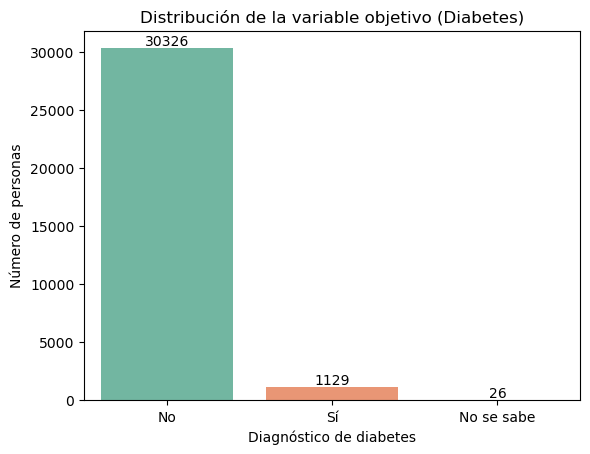

In [19]:
# Distribución de diabetes
data.loc[:, 'DIABETES'] = data['QS109'].map({1: "Sí", 2: "No", 8: "No se sabe"})

ax = sns.countplot(x='DIABETES', hue='DIABETES', data=data, palette='Set2', legend=False)

plt.title("Distribución de la variable objetivo (Diabetes)")
plt.xlabel("Diagnóstico de diabetes")
plt.ylabel("Número de personas")

# Agregar etiquetas con el valor exacto sobre cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10)

plt.show()

El gráfico muestra la distribución de la variable objetivo **diabetes** (QS109) en la población encuestada, donde la mayoría de personas no presenta diagnóstico de diabetes (“No”), mientras que solo una fracción reducida reporta haber sido diagnosticada (“Sí”) y un número mínimo indicó “No se sabe”. Esto refleja un fuerte desbalance de clases, con muchos más casos negativos que positivos en la muestra.

In [20]:
#Valores faltantes: identificar y cuantificar (df.isnull().sum()).
na_counts = data.isna().sum().sort_values(ascending=False)
na_pct = (na_counts/len(data)*100).round(2)
quality_missing = pd.DataFrame({'missing': na_counts, 'missing_%': na_pct})
display(quality_missing)

,missing,missing_%
QS203C,31128,98.87
QS205C,31128,98.87
QS202,28588,90.80
QS201,26555,84.34
QS218C,26069,82.80
QS304,23298,74.00
QS212A,21172,67.25
QS212G,21172,67.25
QS211C,21172,67.25
QS209,10355,32.89


In [21]:
# Definir los rangos esperados
suspects = data[
    (data['QS23'] < 15) | (data['QS23'] > 100) |         # Edad fuera de rango
    (data['QS900'] < 30) | (data['QS900'] > 200) |       # Peso (kg)
    (data['QS901'] < 120) | (data['QS901'] > 220) |      # Talla (cm)
    (data['QS907'] < 50) | (data['QS907'] > 200)         # Perímetro abdominal (cm)
]

print("Número de registros sospechosos (fuera de rangos):", len(suspects))

# Mostrar algunos ejemplos
display(suspects[['QS23','QS900','QS901','QS907']].head(10))

Número de registros sospechosos (fuera de rangos): 840


,QS23,QS900,QS901,QS907
60,28,76.0,163.5,999.9
88,20,50.8,147.2,999.9
113,23,52.7,154.5,999.9
114,25,57.3,157.2,999.9
152,87,999.9,999.9,999.9
217,22,75.7,163.5,999.9
271,41,57.2,149.2,999.9
299,50,999.9,999.9,999.9
401,23,999.9,999.9,999.9
404,35,999.9,999.9,999.9


### 3.5 Perfil estadístico comparativo (Diagnosticados con diabetes vs NO Diagnosticados con diabetes)

In [22]:
# Medias comparativas numéricas (solo variables seleccionadas)
cols = [
    'QS23', 'QS203C', 'QS205C', 'QS207C', 'QS211C',
    'QS213C', 'QS218C', 'QS219C', 'QS900', 'QS901',
    'QS903S', 'QS903D', 'QS905S', 'QS905D', 'QS907'
]

data.groupby('QS109')[cols].mean(numeric_only=True)

,QS23,QS203C,QS205C,QS207C,QS211C,QS213C,QS218C,QS219C,QS900,QS901,QS903S,QS903D,QS905S,QS905D,QS907
QS109,,,,,,,,,,,,,,,
1.0,55.651019,29.125000,5.470588,20.441484,1.904478,4.423729,1.158974,3.661220,94.297163,177.223138,135.655142,86.869681,133.695922,85.990248,127.529078
2.0,39.277880,25.508824,4.244838,19.072193,1.852171,4.313937,1.171010,3.224923,78.409325,167.318881,122.811830,80.871307,121.069380,80.023732,114.542866
8.0,60.923077,NaN,NaN,19.650000,2.166667,3.238095,2.000000,3.000000,60.761538,151.169231,117.961538,72.269231,116.038462,70.538462,91.853846


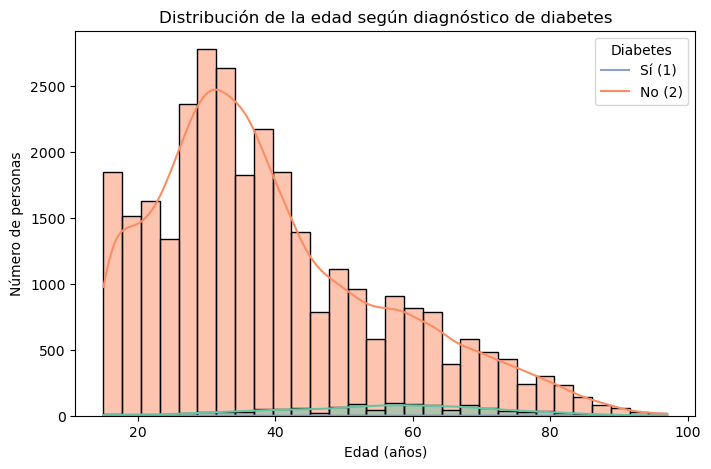

In [23]:
# Comparación gráfica de variables numéricas
plt.figure(figsize=(8,5))
sns.histplot(data=data, x='QS23', hue='QS109', bins=30, kde=True, palette='Set2')
plt.title("Distribución de la edad según diagnóstico de diabetes")
plt.xlabel("Edad (años)")
plt.ylabel("Número de personas")
plt.legend(title="Diabetes", labels=["Sí (1)", "No (2)"])
plt.show()

In [24]:
# Lista de columnas seleccionadas
cols = [
    'QS23', 'QS203C', 'QS205C', 'QS207C', 'QS211C',
    'QS213C', 'QS218C', 'QS219C', 'QS900', 'QS901',
    'QS903S', 'QS903D', 'QS905S', 'QS905D', 'QS907'
]

# Perfil estadístico comparativo (diagnosticados vs no diagnosticados)
perfil_num = data.groupby('QS109')[cols].agg(['mean','median','std','min','max']).round(3)

display(perfil_num)

QS23                         QS203C                             ...  \
         mean median     std min max    mean median     std   min   max  ...   
QS109                                                                    ...   
1.0    55.651   57.0  15.554  15  92  29.125   25.0  12.580  17.0  57.0  ...   
2.0    39.278   36.0  16.721  15  97  25.509   21.0  11.475  10.0  78.0  ...   
8.0    60.923   63.0  20.758  17  94     NaN    NaN     NaN   NaN   NaN  ...   

       QS905D                                QS907                        \
         mean median     std   min    max     mean median      std   min   
QS109                                                                      
1.0    85.990   75.5  95.379  42.0  999.0  127.529   98.3  161.126  64.2   
2.0    80.024   73.0  77.656  40.0  999.0  114.543   90.9  145.347  55.0   
8.0    70.538   71.5   9.729  42.0   90.0   91.854   91.9   12.191  68.5   

              
         max  
QS109         
1.0    999.9  
2.0    999.9  
8.0    111.6  

[3 rows x 75 columns]

### 3.6 Hallazgos

#### Hallazgos del Paso 3: Descriptive analysis

##### 1. Distribución general del dataset
- El dataset contiene **31018 registros y 29 variables**.
- Las variables abarcan información demográfica (edad, sexo), clínica (peso, talla, perímetro abdominal, presión arterial, hipertensión) y de estilo de vida/dieta (tabaco, alcohol, frutas, verduras, jugos).
- La variable objetivo es QS109 (diagnóstico de diabetes o azúcar alta).


##### 2. Variables principales
- **Sexo**: Distribución relativamente equilibrada entre hombres y mujeres. 
- **Hipertensión (QS102)**: Se observa una proporción significativa de personas diagnosticadas, lo cual es un factor de riesgo.  
- **Consumo de tabaco y alcohol**: Predominan respuestas “No consume”, lo que muestra baja prevalencia en la muestra.
- **Edad (QS23)**: el rango va de jóvenes adultos hasta personas mayores. Se concentra más en adultos de mediana edad. 
- **Peso, talla y perímetro abdominal**: Se identifican valores coherentes con el rango esperado, pero también aparecen registros anormales codificados como 999, lo que no representa un valor real. Estos deben tratarse como valores faltantes para no distorsionar los análisis.  
- **Presión arterial**: existen casos con valores elevados, lo que puede asociarse a riesgo cardiovascular.

##### 4. Valores faltantes
- Hay valores nulos en algunas variables, especialmente en preguntas de dieta y consumo.  
- Además, se detectaron valores atípicos artificiales (999) en variables como peso, talla, perímetro abdominal y tambien en la edad de consumo por primera vez, lo cual refleja errores de captura o registros sin respuesta.
- Estos valores deben ser recodificados como NaN para evitar que afecten estadísticas y modelos.

##### 5. Correlaciones
- Existe correlación positiva entre peso, perímetro abdominal y presión arterial, lo que refleja el efecto de la obesidad sobre la salud cardiovascular.  
- Edad se asocia con mayor prevalencia de hipertensión y diabetes.
- El análisis comparativo sugiere que personas mayores y con mayor perímetro abdominal tienen más probabilidad de diagnóstico positivo de diabetes.

##### 6. Perfil comparativo: con diabetes vs sin diabetes
- Con diagnóstico de diabetes: tienden a ser de mayor edad, con valores más altos en perímetro abdominal y mayor prevalencia de hipertensión.
- Sin diagnóstico: suelen ser más jóvenes, con menor perímetro abdominal y menos casos de hipertensión.


# 📌 Fase 3. Data Preparation

## 🧹 4. Data Cleaning

#### 4.1 Selección inicial de variables claves

Queremos construir un modelo que prediga si una persona puede tener diabetes (1) o no (0) sin usar exámenes de laboratorio o mediciones de sangre. Por ello, conservaremos factores como datos demográficos, hábitos de vida, alimentación, mediciones antropométricas, presión arterial y antecedentes relevantes de salud.

🔴 **Variables candidatas a eliminar:**
Estas no aportan a la predicción de diabetes porque son identificadores, redundantes o menos relevantes en el foco de salud metabólica.  

- **QS200** → En los  últimos 12 meses ha fumado cigarrillos.
- **QS201** → En los últimos 30 días ha fumado cigarrillos.    
- **QS210** → En los últimos 30 días ha consumido bebidas alcohólicas.  
- **QS212A** → Tomó cerveza  
- **QS212G** → Tomó Whisky/pisco /ron  
- **QS218C** → Cantidad porciones ensalada frutas.
- **QS304** → Le han diagnosticado Catarata 
- **QS903S** → Primera medición presión arterial sistólica.
- **QS903D** → Primera medición presión arterial diastólica.
- **QS905S** → Segunda medición presión arterial sistólica.  
- **QS905D** → Segunda medición presión arterial diastólica.  

---

🟢 **Variables candidatas a conservar:**
Estas sí son relevantes porque se relacionan directamente con factores de riesgo y diagnóstico de diabetes:  

📊 **Datos demográficos** 
- **QS23** → Edad del entrevistado (años cumplidos).  
- **QSSEXO** → Sexo del entrevistado.  

---

🚬🍷 **Hábitos y estilo de vida**  
- **QS202** → Fuma diariamente.  
- **QS203C** → Edad que empezó a fumar diariamente.  
- **QS205C** → Cantidad de cigarrillos diarios que fuma.  
- **QS206** → Ha consumido alguna vez bebidas alcohólicas. 
- **QS207C** → Edad primera vez que tomo bebidas alcohólicas.
- **QS208** → En los últimos 12 meses ha consumido alguna bebida alcohólica.  
- **QS209** → En los últimos 12 meses, tomó bebidas alcohólicas 12 o más días.  
- **QS211C** → Cantidad de veces que tomo en un mes.  
- **QS213C** → Cantidad de días que consumió frutas.  
- **QS219C** → Días que comió ensalada de verduras.  

---

🩺 **Mediciones clínicas**  
- **QS900** → Personas de 15 años a màs de edad - Peso en kilogramos.  
- **QS901** → Personas de 15 años a màs de edad - Talla en centímetros.  
- **QS907** → Perímetro abdominal (cm).  

---

⚕️ **Antecedentes y diagnóstico**  
- **QS102** → ¿Alguna vez un médico u otro profesional de la salud le dijo que tenía hipertensión?  
- **QS304** → Le han diagnosticado Catarata.  
- **QS500** → Actualmente tiene tos con flema.  

---

🎯 **Variable objetivo**  
- **QS109** → Le diagnosticaron diabetes.

In [25]:
# Variables candidatas a conservar
features_keep = ["QS23", "QSSEXO",
    "QS202", "QS203C", "QS205C",
    "QS206", "QS207C", "QS208", "QS209", 
    "QS211C","QS213C", "QS219C","QS900", 
    "QS901", "QS907", "QS102",
    "QS304", "QS500"]

# Variable objetivo
target = ["QS109"]  # Le diagnosticaron diabetes

# Crear nuevo DataFrame solo con estas variables
df_sel = data[features_keep+target]

# Información básica del nuevo dataset
print("df_sel.shape:", df_sel.shape)
print("df_sel.columns:", df_sel.columns.tolist())
df_sel.head(10)

df_sel.shape: (31484, 19)
df_sel.columns: ['QS23', 'QSSEXO', 'QS202', 'QS203C', 'QS205C', 'QS206', 'QS207C', 'QS208', 'QS209', 'QS211C', 'QS213C', 'QS219C', 'QS900', 'QS901', 'QS907', 'QS102', 'QS304', 'QS500', 'QS109']


,QS23,QSSEXO,QS202,QS203C,QS205C,QS206,QS207C,QS208,QS209,QS211C,QS213C,QS219C,QS900,QS901,QS907,QS102,QS304,QS500,QS109
0,38,2,NaN,NaN,NaN,1.0,17.0,2.0,NaN,NaN,NaN,6.0,70.4,152.5,98.9,2.0,NaN,1.0,2.0
1,17,2,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,3.0,7.0,49.8,160.2,68.4,2.0,NaN,2.0,2.0
2,65,2,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,7.0,6.0,49.7,136.2,86.3,2.0,2.0,2.0,2.0
3,33,1,2.0,NaN,NaN,1.0,17.0,1.0,2.0,4.0,7.0,2.0,76.0,158.2,100.4,2.0,NaN,2.0,2.0
4,30,1,NaN,NaN,NaN,1.0,21.0,2.0,NaN,NaN,5.0,NaN,66.0,159.4,87.2,2.0,NaN,2.0,2.0
5,32,2,NaN,NaN,NaN,1.0,18.0,1.0,2.0,NaN,7.0,2.0,72.9,157.0,91.7,2.0,NaN,2.0,2.0
6,34,2,NaN,NaN,NaN,1.0,26.0,2.0,NaN,NaN,3.0,4.0,57.3,153.3,80.2,2.0,NaN,2.0,2.0
7,18,2,NaN,NaN,NaN,1.0,17.0,1.0,2.0,NaN,3.0,3.0,67.6,151.5,93.2,2.0,NaN,2.0,2.0
8,45,1,NaN,NaN,NaN,1.0,19.0,1.0,2.0,1.0,2.0,6.0,85.7,171.6,101.1,2.0,NaN,2.0,2.0
9,33,2,NaN,NaN,NaN,1.0,24.0,1.0,1.0,1.0,7.0,7.0,81.2,158.3,108.1,2.0,NaN,2.0,2.0


In [26]:
#  Revisar duplicados (en todo el registro de estas columnas)
duplicates_count = df_sel.duplicated().sum()
# df_sel = df_sel.drop_duplicates()
duplicates_count

1

In [27]:
# Revisar valores faltantes
df_sel.isnull().sum()

# Conteo total de valores nulos en el DataFrame
print("Total de valores nulos:", df_sel.isnull().sum().sum())

Total de valores nulos: 163135


In [28]:
#  Porcentaje de valores nulos por columna (más útil para limpieza)
print("\nPorcentaje de nulos por columna:")
print((df_sel.isnull().mean() * 100).round(2))


Porcentaje de nulos por columna:
QS23       0.00
QSSEXO     0.00
QS202     90.80
QS203C    98.87
QS205C    98.87
QS206      0.05
QS207C     9.40
QS208      8.25
QS209     32.89
QS211C    67.25
QS213C     9.69
QS219C    27.65
QS900      0.11
QS901      0.11
QS907      0.10
QS102      0.01
QS304     74.00
QS500      0.09
QS109      0.01
dtype: float64


**Observación**  
Como podemos visualizar existen columanas que tienen una gran cantidad de datos nulos, más del 60%, así que estas vamos a tener que imputarlas porque no aportarán en nada a nuestro modelo.

In [29]:
# Eliminamos las columnas que tengan más del 60% de datos vacios
# Calcular porcentaje de nulos por columna
porc_nulos = df_sel.isna().mean() * 100

# Seleccionar columnas con más del 60% de nulos
cols_a_eliminar = porc_nulos[porc_nulos > 60].index.tolist()

print("Columnas a eliminar (>60% nulos):", cols_a_eliminar)

# Eliminar esas columnas
df_sel = df_sel.drop(columns=cols_a_eliminar)

# Eliminar las columnas
df_sel = df_sel.drop(columns=["QS206", "QS209"])


# Verificar tamaño final del dataset
print("Dataframe final:", df_sel.shape)

Columnas a eliminar (>60% nulos): ['QS202', 'QS203C', 'QS205C', 'QS211C', 'QS304']
Dataframe final: (31484, 12)


In [30]:
#  Porcentaje de valores nulos por columna (verificamos)
print("\nPorcentaje de nulos por columna:")
print((df_sel.isnull().mean() * 100).round(2))


Porcentaje de nulos por columna:
QS23       0.00
QSSEXO     0.00
QS207C     9.40
QS208      8.25
QS213C     9.69
QS219C    27.65
QS900      0.11
QS901      0.11
QS907      0.10
QS102      0.01
QS500      0.09
QS109      0.01
dtype: float64


In [31]:
# Eliminar filas con QS109 nulo
df_limpio = df_sel.dropna(subset=["QS109"])

# Eliminar filas con QS208 nulo
df_limpio = df_sel.dropna(subset=["QS208"])

# Eliminar filas con QS500 nulo
df_limpio = df_limpio.dropna(subset=["QS500"])

#  Porcentaje de valores nulos por columna (verificamos)
print("\nPorcentaje de nulos por columna:")
print((df_limpio.isnull().mean() * 100).round(2))

# Verificar tamaño del dataset
print("Dataframe final:", df_limpio.shape)


Porcentaje de nulos por columna:
QS23       0.00
QSSEXO     0.00
QS207C     1.24
QS208      0.00
QS213C     9.56
QS219C    26.96
QS900      0.03
QS901      0.03
QS907      0.02
QS102      0.00
QS500      0.00
QS109      0.00
dtype: float64
Dataframe final: (28876, 12)


In [32]:
from IPython.display import Markdown, display

# Diccionario de etiquetas (Código → Descripción)
labels = {
    'QS208': "Sfsdsfdsf"
}

# Conteo de valores únicos con etiqueta arriba
for col in labels.keys():
    display(Markdown(f"\n##### {col} → {labels[col]}"))
    print(df_limpio[col].value_counts())



# Conteo de la variable objetivo
display(Markdown("\n\n### QS109 → Le diagnosticaron diabetes"))
df_limpio["QS109"].value_counts()


##### QS208 → Sfsdsfdsf

QS208
1.0    21124
2.0     7746
8.0        6
Name: count, dtype: int64




### QS109 → Le diagnosticaron diabetes

QS109
2.0    27771
1.0     1081
8.0       24
Name: count, dtype: int64

In [33]:
# Reemplazamos los NA por el promedio
cols_promedio = ["QS213C","QS207C" ,"QS900", "QS901", "QS907", "QS219C"]

for col in cols_promedio:
    df_limpio[col] = pd.to_numeric(df_limpio[col], errors="coerce")
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mean())

#  Porcentaje de valores nulos por columna (verificamos)
print("\nPorcentaje de nulos por columna:")
print((df_limpio.isnull().mean() * 100).round(2))


Porcentaje de nulos por columna:
QS23      0.0
QSSEXO    0.0
QS207C    0.0
QS208     0.0
QS213C    0.0
QS219C    0.0
QS900     0.0
QS901     0.0
QS907     0.0
QS102     0.0
QS500     0.0
QS109     0.0
dtype: float64


In [34]:
# Verificamos si hay datos vacios
print("¿Hay nulos en el dataset?:", df_limpio.isnull().values.any())

¿Hay nulos en el dataset?: False


In [35]:
df_limpio.head(10)

,QS23,QSSEXO,QS207C,QS208,QS213C,QS219C,QS900,QS901,QS907,QS102,QS500,QS109
0,38,2,17.0,2.0,4.315413,6.000000,70.4,152.5,98.9,2.0,1.0,2.0
3,33,1,17.0,1.0,7.000000,2.000000,76.0,158.2,100.4,2.0,2.0,2.0
4,30,1,21.0,2.0,5.000000,3.253995,66.0,159.4,87.2,2.0,2.0,2.0
5,32,2,18.0,1.0,7.000000,2.000000,72.9,157.0,91.7,2.0,2.0,2.0
6,34,2,26.0,2.0,3.000000,4.000000,57.3,153.3,80.2,2.0,2.0,2.0
7,18,2,17.0,1.0,3.000000,3.000000,67.6,151.5,93.2,2.0,2.0,2.0
8,45,1,19.0,1.0,2.000000,6.000000,85.7,171.6,101.1,2.0,2.0,2.0
9,33,2,24.0,1.0,7.000000,7.000000,81.2,158.3,108.1,2.0,2.0,2.0
10,36,2,17.0,1.0,7.000000,7.000000,51.3,156.1,77.7,1.0,2.0,2.0
11,36,2,19.0,1.0,1.000000,7.000000,56.8,155.7,91.2,2.0,1.0,2.0


In [36]:
# Verificar tamaño final del dataset
print("Dataframe final:", df_limpio.shape)

Dataframe final: (28876, 12)


**Observación**
Ahora vamos a eliminar los registros que tengan valor **8 = "No lo sé"** en **QS208, QS209, QS102**, porque solo generan ruido.

In [37]:
# Eliminar registros donde QS208, QS209 o QS102 tengan el valor 8
df_limpio = df_limpio[~df_limpio[["QS208", "QS102"]].isin([8]).any(axis=1)]

# Verificar tamaño final
print("Shape después de eliminar registros con '8':", df_limpio.shape)

Shape después de eliminar registros con '8': (28851, 12)


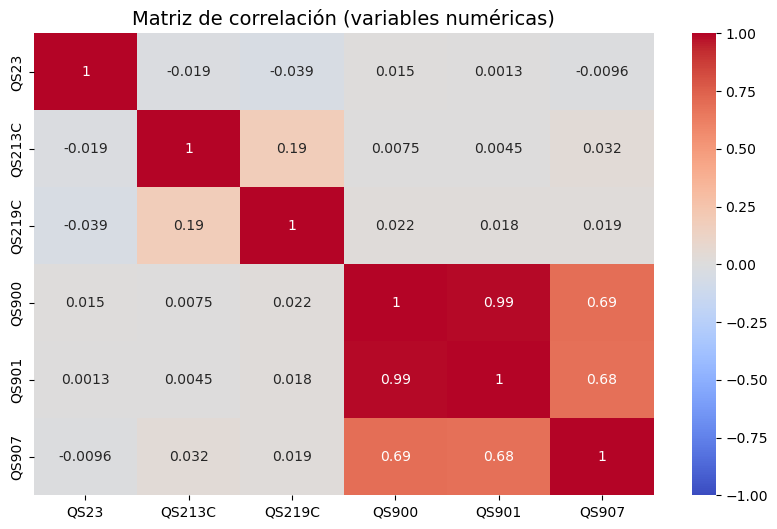

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo las columnas numéricas
cols_num = ["QS23", "QS213C", "QS219C", "QS900", "QS901", "QS907"]

# Calcular matriz de correlación
corr = df_limpio[cols_num].corr()

# Graficar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlación (variables numéricas)", fontsize=14)
plt.show()

In [39]:
corr_target = df_limpio[cols_num + ["QS109"]].corr()["QS109"].sort_values(ascending=False)
print(corr_target)

QS109     1.000000
QS213C   -0.013989
QS907    -0.014653
QS901    -0.015756
QS900    -0.021759
QS219C   -0.028464
QS23     -0.108501
Name: QS109, dtype: float64


#### 4.2 Analisis de OutLiers del data frame df_limpio

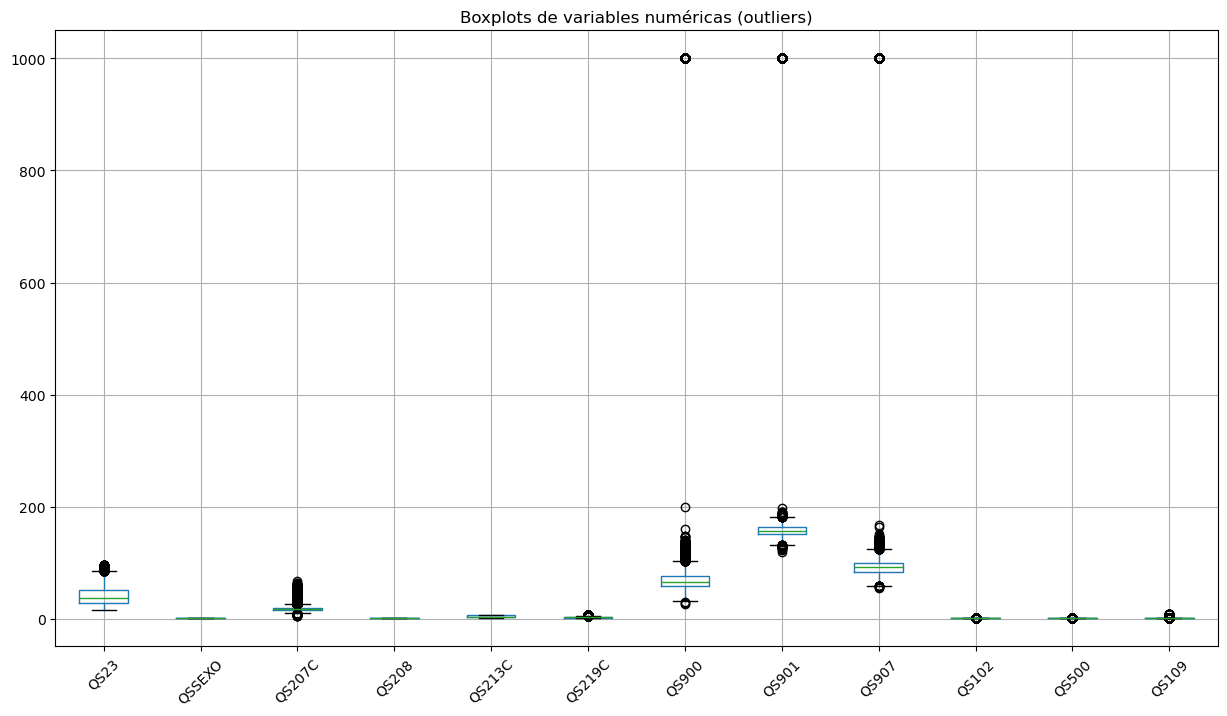

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo columnas numéricas
num_cols = df_limpio.select_dtypes(include=['float64', 'int64']).columns

# Crear boxplots
plt.figure(figsize=(15, 8))
df_limpio[num_cols].boxplot()
plt.title("Boxplots de variables numéricas (outliers)")
plt.xticks(rotation=45)
plt.show()


In [41]:
# Hacer una copia del dataset limpio
df_sin_outliers = df_limpio.copy()

# Función para recortar (winsorizar)
def cortar_outliers(df, col, min_val, max_val):
    df[col] = df[col].clip(lower=min_val, upper=max_val)
    return df

# Aplicar cortes en variables numéricas con rangos lógicos
df_sin_outliers = cortar_outliers(df_sin_outliers, "QS207C", 5, 70)     # edad primera vez alcohol
df_sin_outliers = cortar_outliers(df_sin_outliers, "QS900", 30, 200)    # peso
df_sin_outliers = cortar_outliers(df_sin_outliers, "QS901", 120, 210)   # talla
df_sin_outliers = cortar_outliers(df_sin_outliers, "QS907", 40, 160)    # perímetro abdominal

# Verificar cambios
print(df_sin_outliers[["QS207C","QS900","QS901","QS907"]].describe())


            QS207C         QS900         QS901         QS907
count  28851.00000  28851.000000  28851.000000  28851.000000
mean      19.11910     69.224233    157.676500     93.389982
std        4.83983     20.380810     10.491819     15.914446
min        5.00000     30.000000    120.000000     55.000000
25%       16.00000     57.900000    150.700000     83.700000
50%       18.00000     66.400000    156.600000     91.700000
75%       20.00000     76.000000    163.300000     99.900000
max       68.00000    200.000000    210.000000    160.000000


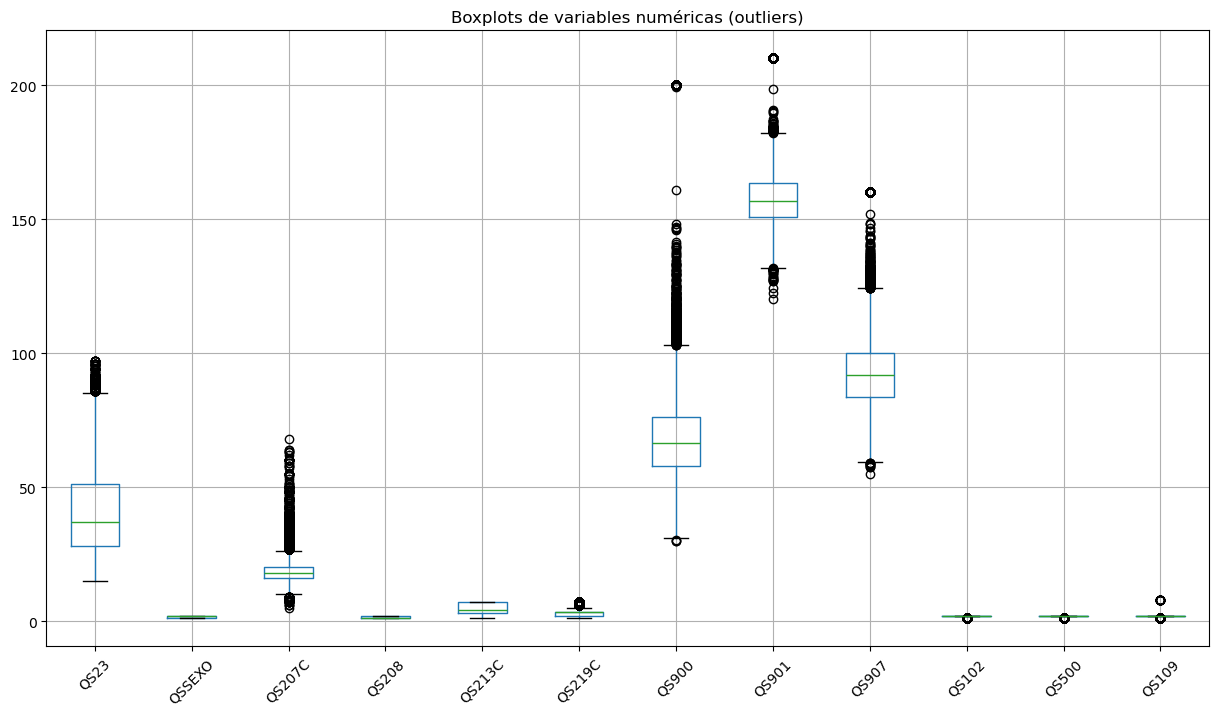

In [42]:
# Seleccionar solo columnas numéricas
num_cols = df_sin_outliers.select_dtypes(include=['float64', 'int64']).columns

# Crear boxplots
plt.figure(figsize=(15, 8))
df_sin_outliers[num_cols].boxplot()
plt.title("Boxplots de variables numéricas (outliers)")
plt.xticks(rotation=45)
plt.show()


In [50]:
df_sin_outliers

,QS23,QSSEXO,QS207C,QS208,QS213C,QS219C,QS900,QS901,QS907,QS102,QS500,QS109
0,38,2,17.0,2.0,4.315413,6.000000,70.4,152.5,98.9,2.0,1.0,2.0
3,33,1,17.0,1.0,7.000000,2.000000,76.0,158.2,100.4,2.0,2.0,2.0
4,30,1,21.0,2.0,5.000000,3.253995,66.0,159.4,87.2,2.0,2.0,2.0
5,32,2,18.0,1.0,7.000000,2.000000,72.9,157.0,91.7,2.0,2.0,2.0
6,34,2,26.0,2.0,3.000000,4.000000,57.3,153.3,80.2,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
31479,35,2,20.0,1.0,7.000000,3.000000,65.9,152.0,92.9,2.0,2.0,2.0
31480,15,1,14.0,1.0,2.000000,3.000000,54.5,164.0,69.9,2.0,2.0,2.0
31481,31,2,20.0,2.0,3.000000,7.000000,58.4,153.0,84.1,2.0,2.0,2.0
31482,35,2,18.0,2.0,4.315413,3.253995,58.4,148.9,90.5,2.0,2.0,2.0


In [47]:
df_categorizado = df_sin_outliers.copy()

# 3. Reglas de conversión
# QSEXO: 1 -> Masculino, 2 -> Femenino
df_categorizado['QSSEXO'] = df_categorizado['QSSEXO'].map({1: 'Masculino', 2: 'Femenino'})
df_categorizado['QS109'] = df_categorizado['QS109'].map({1: 'Tiene', 2: 'No-tiene'})

# Resto de columnas: 1 -> Sí, 2 -> No
cols_si_no = ['QS208', 'QS102', 'QS500']

for col in cols_si_no:
    df_categorizado[col] = df_categorizado[col].map({1: 'Sí', 2: 'No'})

df_categorizado = df_categorizado.dropna(subset=['QS109'])

# 4. Guardar el nuevo DataFrame en un CSV
df_categorizado.to_csv("df_sin_outliers_categorizado.csv", index=False, encoding='utf-8-sig')

# 5. Mostrar confirmación
print("✅ Archivo 'df_sin_outliers_categorizado.csv' generado con éxito.")
print("Columnas convertidas:", ['QSEXO'] + cols_si_no)

In [48]:
df_categorizado

,QS23,QSSEXO,QS207C,QS208,QS213C,QS219C,QS900,QS901,QS907,QS102,QS500,QS109
0,38,Femenino,17.0,No,4.315413,6.000000,70.4,152.5,98.9,No,Sí,No-tiene
3,33,Masculino,17.0,Sí,7.000000,2.000000,76.0,158.2,100.4,No,No,No-tiene
4,30,Masculino,21.0,No,5.000000,3.253995,66.0,159.4,87.2,No,No,No-tiene
5,32,Femenino,18.0,Sí,7.000000,2.000000,72.9,157.0,91.7,No,No,No-tiene
6,34,Femenino,26.0,No,3.000000,4.000000,57.3,153.3,80.2,No,No,No-tiene
...,...,...,...,...,...,...,...,...,...,...,...,...
31479,35,Femenino,20.0,Sí,7.000000,3.000000,65.9,152.0,92.9,No,No,No-tiene
31480,15,Masculino,14.0,Sí,2.000000,3.000000,54.5,164.0,69.9,No,No,No-tiene
31481,31,Femenino,20.0,No,3.000000,7.000000,58.4,153.0,84.1,No,No,No-tiene
31482,35,Femenino,18.0,No,4.315413,3.253995,58.4,148.9,90.5,No,No,No-tiene


En el caso de nuestra data, no es necesario utilizar el Laber Encoding para codificar nuestra variable objetivo (QS109). Sin embargo, lo que haremos sera convertir nuestro dato en un valor binario ya que por defecto este viene con 1 (Si) y 2 (No).

In [46]:
#Almacenamos los datos de la data limpia en una nueva variable para trabajar en esta
data_cod = df_sin_outliers
data_cod.head(10)

,QS23,QSSEXO,QS207C,QS208,QS213C,QS219C,QS900,QS901,QS907,QS102,QS500,QS109
0,38,2,17.0,2.0,4.315413,6.000000,70.4,152.5,98.9,2.0,1.0,2.0
3,33,1,17.0,1.0,7.000000,2.000000,76.0,158.2,100.4,2.0,2.0,2.0
4,30,1,21.0,2.0,5.000000,3.253995,66.0,159.4,87.2,2.0,2.0,2.0
5,32,2,18.0,1.0,7.000000,2.000000,72.9,157.0,91.7,2.0,2.0,2.0
6,34,2,26.0,2.0,3.000000,4.000000,57.3,153.3,80.2,2.0,2.0,2.0
7,18,2,17.0,1.0,3.000000,3.000000,67.6,151.5,93.2,2.0,2.0,2.0
8,45,1,19.0,1.0,2.000000,6.000000,85.7,171.6,101.1,2.0,2.0,2.0
9,33,2,24.0,1.0,7.000000,7.000000,81.2,158.3,108.1,2.0,2.0,2.0
10,36,2,17.0,1.0,7.000000,7.000000,51.3,156.1,77.7,1.0,2.0,2.0
11,36,2,19.0,1.0,1.000000,7.000000,56.8,155.7,91.2,2.0,1.0,2.0


Listo, esta seria nuestra data final para poder utilizar durante la segunda unidad y todo lo que tiene relacion con el modelo que se va a realizar.

# 📌 Fase 4 y 5: Modeling & Evaluation

In [9]:
# =========================================
# 1) Cargar datos y preparar variable objetivo
# =========================================
import os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Semilla aleatoria
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Archivo y variable objetivo
DATA_FILE = "df_sin_outliers_categorizado.csv"   # tu archivo procesado
TARGET    = "QS109"                              # indica si tiene diabetes

# Verificar existencia del archivo
assert os.path.exists(DATA_FILE), f"No se encuentra {DATA_FILE}"

# Leer dataset
df = pd.read_csv(DATA_FILE)

# Mapear los valores de QS109: "Tiene" → 1 (tiene diabetes), "No-tiene" → 0 (no tiene)
label_map = {"Tiene": 1, "No-tiene": 0}
df[TARGET] = df[TARGET].map(label_map).astype(int)

# =========================================
# 🔹 Corte manual antes del split (balanceo)
# =========================================

# Separar las clases
df_0 = df[df[TARGET] == 0]
df_1 = df[df[TARGET] == 1]

# Definir tamaños deseados (como tu imagen)
n0, n1 = 1300, 1079

# Asegurar que no se pida más de lo disponible
n0 = min(n0, len(df_0))
n1 = min(n1, len(df_1))

# Tomar muestras aleatorias de cada clase
df_0_sample = df_0.sample(n=n0, random_state=RANDOM_STATE)
df_1_sample = df_1.sample(n=n1, random_state=RANDOM_STATE)

# Combinar y mezclar
df_balanced = pd.concat([df_0_sample, df_1_sample]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Mostrar balance resultante
print("Distribución balanceada:")
print(df_balanced[TARGET].value_counts())

# =========================================
# 2) Definir X e y con el dataset balanceado
# =========================================
X = df_balanced.drop(columns=[TARGET])
y = df_balanced[TARGET]

print("Shape:", X.shape, "| Proporción (tiene diabetes=1):", round((y == 1).mean(), 3))
print("Primeras etiquetas de y:", y.head().tolist())


Distribución balanceada:
QS109
0    1300
1    1079
Name: count, dtype: int64
Shape: (2379, 11) | Proporción (tiene diabetes=1): 0.454
Primeras etiquetas de y: [0, 0, 0, 1, 1]


In [13]:
df_balanced

,QS23,QSSEXO,QS207C,QS208,QS213C,QS219C,QS900,QS901,QS907,QS102,QS500,QS109
0,36,Femenino,18.0,Sí,2.000000,2.000000,70.2,147.8,91.0,No,Sí,0
1,66,Masculino,14.0,Sí,2.000000,3.253995,63.9,161.9,88.8,No,No,0
2,60,Femenino,19.0,Sí,7.000000,3.000000,64.8,148.7,85.2,No,No,0
3,61,Masculino,18.0,Sí,1.000000,2.000000,86.8,174.0,101.0,No,No,1
4,30,Femenino,17.0,Sí,7.000000,3.000000,74.3,150.3,95.7,No,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2374,50,Femenino,22.0,No,7.000000,3.000000,54.7,148.6,81.1,Sí,No,1
2375,28,Masculino,17.0,Sí,3.000000,1.000000,58.7,162.4,79.9,No,No,0
2376,55,Femenino,18.0,No,7.000000,3.000000,91.9,156.1,111.3,Sí,No,0
2377,51,Masculino,25.0,No,4.315413,3.000000,73.9,170.0,92.9,No,No,0


In [14]:
df_balanced['QS109'].value_counts()

QS109
0    1300
1    1079
Name: count, dtype: int64

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28828 entries, 0 to 28827
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   QS23    28828 non-null  int64  
 1   QSSEXO  28828 non-null  object 
 2   QS207C  28828 non-null  float64
 3   QS208   28828 non-null  object 
 4   QS213C  28828 non-null  float64
 5   QS219C  28828 non-null  float64
 6   QS900   28828 non-null  float64
 7   QS901   28828 non-null  float64
 8   QS907   28828 non-null  float64
 9   QS102   28828 non-null  object 
 10  QS500   28828 non-null  object 
 11  QS109   28828 non-null  int64  
dtypes: float64(6), int64(2), object(4)
memory usage: 2.6+ MB


In [17]:
# =========================================
# 2) Split temprano (80/20)
# =========================================
from sklearn.model_selection import train_test_split

X = df_balanced.drop(columns=[TARGET])
y = df_balanced[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Distribución en TRAIN:\n", y_train.value_counts())
print("Distribución en TEST:\n", y_test.value_counts())


Train: (1903, 11) | Test: (476, 11)
Distribución en TRAIN:
 QS109
0    1040
1     863
Name: count, dtype: int64
Distribución en TEST:
 QS109
0    260
1    216
Name: count, dtype: int64


In [18]:
# =========================================
# 3) Preprocesamiento (en pipeline)
# =========================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

cat_features = X_train.select_dtypes(include=["object","category"]).columns.tolist()
num_features = X_train.select_dtypes(include=["number","bool"]).columns.tolist()

# OHE compatible (si tu sklearn no soporta sparse_output, cambia a sparse=False)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features),
    ]
)

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)

def build_pipe(model):
    return ImbPipeline([("prep", preprocessor), ("smote", smote), ("model", model)])

In [19]:
# =========================================
# 4) Modelos candidatos
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

candidates = [
    ("LRN", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("LDA", LinearDiscriminantAnalysis()),
    ("KNN", KNeighborsClassifier()),
    ("GNB", GaussianNB()),
    ("DTS", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ("RFS", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ("NNM", MLPClassifier(hidden_layer_sizes=(64,), max_iter=600, random_state=RANDOM_STATE)),
    ("XGB", XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=RANDOM_STATE,
                          n_estimators=400, learning_rate=0.05, max_depth=6,
                          subsample=0.9, colsample_bytree=0.9, n_jobs=-1)),
    ("LGB", LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=-1,
                           subsample=0.9, colsample_bytree=0.9,
                           random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)),
    ("CAT", CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6,
                               random_state=RANDOM_STATE, l2_leaf_reg=3.0,
                               verbose=False, allow_writing_files=False, thread_count=-1)),
]

In [20]:
# =========================================
# 5) Entrenar Baseline con CV (sin tuning)
# =========================================
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy":"accuracy", "f1_macro":"f1_macro", "roc_auc":"roc_auc"}

baseline_rows = []
for name, model in candidates:
    pipe = build_pipe(model)
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_rows.append({
        "model":name,
        "acc_mean":scores["test_accuracy"].mean(),
        "acc_std" :scores["test_accuracy"].std(),
        "f1_mean" :scores["test_f1_macro"].mean(),
        "f1_std"  :scores["test_f1_macro"].std(),
        "auc_mean":scores["test_roc_auc"].mean(),
    })
    print(f"{name:>4} | ACC {scores['test_accuracy'].mean():.3f} "
          f"| F1 {scores['test_f1_macro'].mean():.3f} | AUC {scores['test_roc_auc'].mean():.3f}")

baseline_df = pd.DataFrame(baseline_rows).sort_values("f1_mean", ascending=False)
display(baseline_df)

baseline_best_name  = baseline_df.iloc[0]["model"]
baseline_best_model = dict(candidates)[baseline_best_name]
print(f">>> Baseline ganador: {baseline_best_name}")


 LRN | ACC 0.745 | F1 0.743 | AUC 0.804
 LDA | ACC 0.742 | F1 0.739 | AUC 0.803
 KNN | ACC 0.699 | F1 0.697 | AUC 0.739
 GNB | ACC 0.706 | F1 0.688 | AUC 0.783
 DTS | ACC 0.631 | F1 0.628 | AUC 0.628
 RFS | ACC 0.741 | F1 0.739 | AUC 0.792


/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptro

 NNM | ACC 0.726 | F1 0.724 | AUC 0.777
 XGB | ACC 0.708 | F1 0.705 | AUC 0.770
 LGB | ACC 0.695 | F1 0.691 | AUC 0.757
 CAT | ACC 0.736 | F1 0.734 | AUC 0.781


,model,acc_mean,acc_std,f1_mean,f1_std,auc_mean
0,LRN,0.745124,0.018782,0.742869,0.018707,0.803739
1,LDA,0.741970,0.017380,0.739275,0.017012,0.803342
5,RFS,0.741445,0.014914,0.738859,0.015516,0.791686
9,CAT,0.736191,0.021994,0.734136,0.021791,0.780620
6,NNM,0.726193,0.026176,0.723742,0.026073,0.776658
7,XGB,0.707816,0.016042,0.705332,0.016499,0.769654
2,KNN,0.698874,0.022748,0.696873,0.022387,0.739012
8,LGB,0.694669,0.021194,0.691257,0.021675,0.757111
3,GNB,0.705729,0.017493,0.687587,0.018013,0.782624
4,DTS,0.631095,0.015424,0.628284,0.015518,0.628473


>>> Baseline ganador: LRN


In [21]:
# =========================================
# 6) Tuning con CV y elección del ganador (rápido)
# =========================================
import tempfile, shutil
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform
try:
    from scipy.stats import loguniform
except Exception:
    from sklearn.utils.fixes import loguniform  # fallback

cv_light = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_heavy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_spaces = {
    "LRN":{"model__C":loguniform(1e-2,1e1),"model__penalty":["l2"],
           "model__solver":["lbfgs","liblinear"],"model__class_weight":[None,"balanced"]},
    "RFS":{"model__n_estimators":randint(200,500),"model__max_depth":randint(4,14),
           "model__min_samples_split":randint(2,16),"model__min_samples_leaf":randint(1,8),
           "model__max_features":["sqrt","log2",None],"model__bootstrap":[True,False]},
    "XGB":{"model__n_estimators":randint(250,600),"model__learning_rate":loguniform(5e-3,2e-1),
           "model__max_depth":randint(3,9),"model__subsample":uniform(0.7,0.3),
           "model__colsample_bytree":uniform(0.7,0.3),"model__min_child_weight":randint(1,6)},
    "LGB":{"model__n_estimators":randint(300,800),"model__learning_rate":loguniform(5e-3,2e-1),
           "model__num_leaves":randint(16,128),"model__max_depth":randint(-1,12),
           "model__min_child_samples":randint(10,50),"model__subsample":uniform(0.7,0.3),
           "model__colsample_bytree":uniform(0.7,0.3),"model__reg_lambda":loguniform(1e-3,10)},
    "CAT":{"model__iterations":randint(300,700),"model__learning_rate":loguniform(5e-3,2e-1),
           "model__depth":randint(4,10),"model__l2_leaf_reg":loguniform(1e-2,30),
           "model__border_count":randint(32,255)},
}

to_tune = [
    ("LRN", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("RFS", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
    ("XGB", XGBClassifier(tree_method="hist", eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1)),
    ("LGB", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbosity=-1)),
    ("CAT", CatBoostClassifier(random_state=RANDOM_STATE, verbose=False, allow_writing_files=False, thread_count=1)),
]

refit_metric = "f1_macro"
scoring_opt = {"f1_macro":"f1_macro", "roc_auc":"roc_auc", "accuracy":"accuracy"}

best_models, opt_rows = [], []
cache_dir = tempfile.mkdtemp(prefix="skcache_")

try:
    for name, base_model in to_tune:
        pipe = build_pipe(base_model)
        try: pipe.set_params(memory=cache_dir)
        except: pass
        heavy = name in ["XGB","LGB","CAT"]
        search = RandomizedSearchCV(
            pipe, param_spaces[name],
            n_iter=(15 if heavy else 12), cv=(cv_heavy if heavy else cv_light),
            scoring=scoring_opt, refit=refit_metric, n_jobs=-1,
            random_state=RANDOM_STATE, verbose=1, return_train_score=False,
            error_score=np.nan
        )
        search.fit(X_train, y_train)
        best_models.append((name, search.best_estimator_, search.best_score_, search.best_params_))
    best_models.sort(key=lambda x: (x[2] if pd.notna(x[2]) else -1), reverse=True)
    best_name, final_pipe_opt, best_cv_f1, best_params = best_models[0]
    print(f">>> GANADOR OPTIMIZADO: {best_name} (F1 CV={best_cv_f1:.4f})")
finally:
    shutil.rmtree(cache_dir, ignore_errors=True)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Fitting 3 folds for each of 15 candidates, totalling 45 fits
>>> GANADOR OPTIMIZADO: CAT (F1 CV=0.7557)


In [22]:
# =========================================
# 7) Comparación justa (solo CV) - baseline vs ganador
# =========================================
from sklearn.model_selection import StratifiedKFold, cross_validate

same_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

pipe_baseline_best = build_pipe(baseline_best_model)
pipe_tuned_best    = final_pipe_opt

def cv_summary(pipe, name):
    scores = cross_validate(pipe, X_train, y_train, cv=same_cv,
                            scoring={"f1_macro":"f1_macro","roc_auc":"roc_auc","accuracy":"accuracy"},
                            n_jobs=-1)
    print(f"{name}: F1 {scores['test_f1_macro'].mean():.4f}±{scores['test_f1_macro'].std():.4f} | "
          f"AUC {scores['test_roc_auc'].mean():.4f} | ACC {scores['test_accuracy'].mean():.4f}")
    return scores["test_f1_macro"].mean()

f1_base = cv_summary(pipe_baseline_best, f"Baseline({baseline_best_name})")
f1_tune = cv_summary(pipe_tuned_best,   f"Tuned({best_name})")

# Regla: si la mejora < 0.005, elige el más simple (baseline); si no, el tuned.
if (f1_tune - f1_base) >= 0.005:
    winner_name, winner_pipe = best_name, pipe_tuned_best
else:
    winner_name, winner_pipe = baseline_best_name, pipe_baseline_best

print(f">>> Modelo seleccionado para TEST: {winner_name}")


Baseline(LRN): F1 0.7486±0.0235 | AUC 0.8038 | ACC 0.7509
Tuned(CAT): F1 0.7530±0.0210 | AUC 0.8103 | ACC 0.7551
>>> Modelo seleccionado para TEST: LRN


In [23]:
# =========================================
# 8) Política de decisión (mínima)
# =========================================
# TODO: más adelante optimizar el umbral con CV (máx F1 o meta Precision/Recall).
BEST_THR = 0.50
print(f"Umbral de decisión (provisorio): {BEST_THR}")

Umbral de decisión (provisorio): 0.5


In [24]:
# =========================================
# 9) Evaluación final en TEST
# =========================================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

winner_pipe.fit(X_train, y_train)
proba_test = winner_pipe.predict_proba(X_test)[:, 1]
y_pred     = (proba_test >= BEST_THR).astype(int)

print("\n== Reporte en TEST ==")
print(classification_report(y_test, y_pred, digits=4))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, proba_test))
print("PR-AUC :", average_precision_score(y_test, proba_test))



== Reporte en TEST ==
              precision    recall  f1-score   support

           0     0.7528    0.7731    0.7628       260
           1     0.7177    0.6944    0.7059       216

    accuracy                         0.7374       476
   macro avg     0.7353    0.7338    0.7343       476
weighted avg     0.7369    0.7374    0.7370       476

Matriz de confusión:
 [[201  59]
 [ 66 150]]
ROC-AUC: 0.823201566951567
PR-AUC : 0.7894068158750389


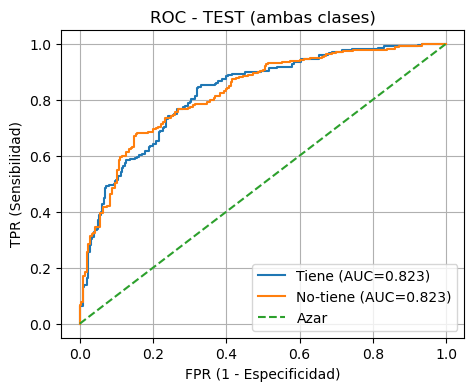

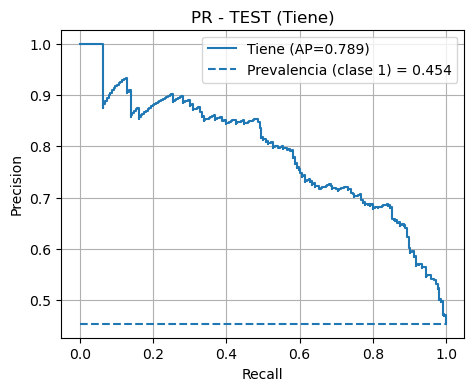

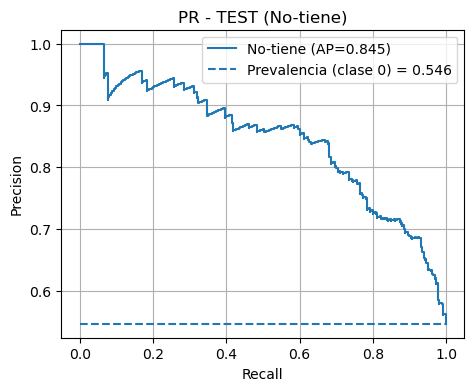

In [25]:
# === Curvas ROC y PR para ambas clases (Tiene=1 y No-tiene=0) ===
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Probabilidades por clase
proba = winner_pipe.predict_proba(X_test)
proba1 = proba[:, 1]  # 
proba0 = proba[:, 0]  # 

y_true = np.asarray(y_test)

# -------- ROC --------
# Clase 1 (Tiene)
fpr1, tpr1, _ = roc_curve(y_true, proba1)
roc_auc1 = auc(fpr1, tpr1)

# Clase 0 (No-tiene): hacemos positiva a la clase 0
y_true0 = 1 - y_true
fpr0, tpr0, _ = roc_curve(y_true0, proba0)
roc_auc0 = auc(fpr0, tpr0)

plt.figure(figsize=(5.2, 4))
plt.plot(fpr1, tpr1, label=f"Tiene (AUC={roc_auc1:.3f})")
plt.plot(fpr0, tpr0, label=f"No-tiene (AUC={roc_auc0:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Azar")
plt.xlabel("FPR (1 - Especificidad)")
plt.ylabel("TPR (Sensibilidad)")
plt.title("ROC - TEST (ambas clases)")
plt.legend()
plt.grid(True)
plt.show()

# -------- PR (Precision-Recall) --------
# Clase 1 (Tiene)
prec1, rec1, _ = precision_recall_curve(y_true, proba1)
ap1 = average_precision_score(y_true, proba1)
prev1 = y_true.mean()  # prevalencia de clase 1

plt.figure(figsize=(5.2, 4))
plt.step(rec1, prec1, where="post", label=f"Tiene (AP={ap1:.3f})")
plt.hlines(prev1, 0, 1, linestyles="--", label=f"Prevalencia (clase 1) = {prev1:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR - TEST (Tiene)")
plt.legend()
plt.grid(True)
plt.show()

# Clase 0 (No-tiene) como positiva
prec0, rec0, _ = precision_recall_curve(y_true0, proba0)
ap0 = average_precision_score(y_true0, proba0)
prev0 = y_true0.mean()  # = 1 - prev1

plt.figure(figsize=(5.2, 4))
plt.step(rec0, prec0, where="post", label=f"No-tiene (AP={ap0:.3f})")
plt.hlines(prev0, 0, 1, linestyles="--", label=f"Prevalencia (clase 0) = {prev0:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR - TEST (No-tiene)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# =========================================
# 10) Interpretabilidad + breve error analysis (pendiente)
# =========================================
# TODO: añadir (según modelo):
#  - Importancias (Permutation Importance) o Coeficientes (LogReg) / SHAP.
#  - Listar 10 FP y 10 FN con sus principales features para análisis.


In [30]:
# =========================================
# 11) Exportar artefactos (mínimo)
# =========================================
import sklearn
import joblib
import json
import platform


version_id = "v1"  # o datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
ART_DIR = os.path.join("artefactos", version_id)
os.makedirs(ART_DIR, exist_ok=True)

# Pipeline
pipe_path = os.path.join(ART_DIR, f"pipeline_{winner_name}.joblib")
joblib.dump(winner_pipe, pipe_path)

# Esquema y mapa de etiquetas
schema = {c: str(X[c].dtype) for c in X.columns}
json.dump(schema, open(os.path.join(ART_DIR, "input_schema.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)
json.dump({"No-tiene":0,"Tiene":1}, open(os.path.join(ART_DIR, "label_map.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)

# Política de decisión (usa BEST_THR provisional)
from sklearn.metrics import f1_score, precision_score, recall_score
def pack_metrics(y_true, proba, thr):
    yp = (proba >= thr).astype(int)
    return {
        "f1": float(f1_score(y_true, yp)),
        "precision": float(precision_score(y_true, yp, zero_division=0)),
        "recall": float(recall_score(y_true, yp)),
        "roc_auc": float(roc_auc_score(y_true, proba)),
        "pr_auc": float(average_precision_score(y_true, proba)),
        "confusion_matrix": confusion_matrix(y_true, yp).tolist()
    }
decision = {
    "winner": winner_name,
    "threshold": float(BEST_THR),
    "test_metrics": pack_metrics(y_test, proba_test, BEST_THR)
}
json.dump(decision, open(os.path.join(ART_DIR, "decision_policy.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)

# Model Card mínima
model_card_md = f"""# Model Card — {winner_name}
**Versión:** {version_id}  
**Sistema:** Python {platform.python_version()}, scikit-learn {sklearn.__version__}

## Datos
Archivo: `{DATA_FILE}` | Shape: {X.shape} | Objetivo: `{TARGET}` (No-tiene=0, Tiene=1) | Prevalencia: {y.mean():.3f}

## Entrenamiento
Split 80/20 estratificado (random_state={RANDOM_STATE}). Preprocesamiento: StandardScaler (num) + OneHotEncoder(ignore) (cat) + SMOTE(k=3).

## Modelo
Seleccionado para TEST: **{winner_name}**.  
Umbral de decisión: **{BEST_THR:.2f}** (provisional).

## Métricas en TEST
F1={decision['test_metrics']['f1']:.3f}, P={decision['test_metrics']['precision']:.3f}, R={decision['test_metrics']['recall']:.3f},
ROC-AUC={decision['test_metrics']['roc_auc']:.3f}, PR-AUC={decision['test_metrics']['pr_auc']:.3f}.
"""
open(os.path.join(ART_DIR,"model_card.md"),"w",encoding="utf-8").write(model_card_md)

# Ejemplos de entrada (5 primeros de TEST)
json.dump(X_test.iloc[:5].to_dict(orient="records"),
          open(os.path.join(ART_DIR,"sample_inputs.json"),"w",encoding="utf-8"),
          ensure_ascii=False, indent=2)

print(f"Artefactos guardados en: {ART_DIR}")

Artefactos guardados en: artefactos/v1


In [31]:
# =========================================
# 12) Cargar artefactos y servir inferencia (mínimo)
# =========================================
import json, pandas as pd, numpy as np

ART_DIR = os.path.join("artefactos","v1")   # ajusta si cambias versión
INPUT_SCHEMA = json.load(open(os.path.join(ART_DIR,"input_schema.json"),"r",encoding="utf-8"))
LABEL_MAP    = json.load(open(os.path.join(ART_DIR,"label_map.json"),"r",encoding="utf-8"))
POLICY       = json.load(open(os.path.join(ART_DIR,"decision_policy.json"),"r",encoding="utf-8"))

WINNER    = POLICY["winner"]
THRESHOLD = float(POLICY.get("threshold", 0.5))
PIPE      = joblib.load(os.path.join(ART_DIR, f"pipeline_{WINNER}.joblib"))
REV_LABEL = {v:k for k,v in LABEL_MAP.items()}
FEATURES  = list(INPUT_SCHEMA.keys())

def _coerce_and_align(df):
    for c,t in INPUT_SCHEMA.items():
        if c not in df.columns: df[c]=np.nan
        if str(t).startswith(("int","float")): df[c]=pd.to_numeric(df[c], errors="coerce")
        elif str(t).lower() in ("bool","boolean"): df[c]=df[c].astype("bool")
        else: df[c]=df[c].astype("string")
    return df[FEATURES]

def predict_batch(records, thr=None):
    thr = THRESHOLD if thr is None else float(thr)
    if isinstance(records, dict): records=[records]
    df = _coerce_and_align(pd.DataFrame(records))
    p  = PIPE.predict_proba(df)[:,1]
    y  = (p>=thr).astype(int)
    return [{"proba":float(pi), "pred_int":int(yi), "pred_label":REV_LABEL[int(yi)], "threshold":thr}
            for pi,yi in zip(p,y)]

# Smoke mínimo con los samples exportados
SAMPLES_JSON = os.path.join(ART_DIR,"sample_inputs.json")
if os.path.exists(SAMPLES_JSON):
    samples = json.load(open(SAMPLES_JSON,"r",encoding="utf-8"))
    print(predict_batch(samples)[:3])


[{'proba': 0.2040430285297947, 'pred_int': 0, 'pred_label': 'No-tiene', 'threshold': 0.5}, {'proba': 0.9068459171651607, 'pred_int': 1, 'pred_label': 'Tiene', 'threshold': 0.5}, {'proba': 0.2758508179923912, 'pred_int': 0, 'pred_label': 'No-tiene', 'threshold': 0.5}]


In [32]:
payload_one = { k: (0 if str(t).startswith(("int","float")) else ("",)[0]) for k,t in INPUT_SCHEMA.items() }
payload_one

{'QS23': 0,
 'QSSEXO': '',
 'QS207C': 0,
 'QS208': '',
 'QS213C': 0,
 'QS219C': 0,
 'QS900': 0,
 'QS901': 0,
 'QS907': 0,
 'QS102': '',
 'QS500': ''}

In [38]:
# =========================================
# 🔍 Prueba de inferencia manual (samples_json)
# =========================================

samples_json = """
[
  {
    "QS23": 37,
    "QSSEXO": "Masculino",
    "QS207C": 19,
    "QS208": "Sí",
    "QS213C": 2,
    "QS219C": 2,
    "QS900": 70.2,
    "QS901": 150,
    "QS907": 91,
    "QS102": "No",
    "QS500": "Sí"
  },
  {
    "QS23": 60,
    "QSSEXO": "Femenino",
    "QS207C": 20,
    "QS208": "No",
    "QS213C": 90,
    "QS219C": 80,
    "QS900": 70,
    "QS901": 166,
    "QS907": 87,
    "QS102": "No",
    "QS500": "No"
  },
  {
    "QS23": 25,
    "QSSEXO": "Femenino",
    "QS207C": 30,
    "QS208": "Sí",
    "QS213C": 30,
    "QS219C": 65,
    "QS900": 80,
    "QS901": 170,
    "QS907": 100,
    "QS102": "Sí",
    "QS500": "Sí"
  }
]
""".strip()

import json
samples_from_json = json.loads(samples_json)

# 🔮 Ejecutar inferencia
res = predict_batch(samples_from_json)
res

[{'proba': 0.21819791842205175,
  'pred_int': 0,
  'pred_label': 'No-tiene',
  'threshold': 0.5},
 {'proba': 0.9999771458284101,
  'pred_int': 1,
  'pred_label': 'Tiene',
  'threshold': 0.5},
 {'proba': 0.9994876469616417,
  'pred_int': 1,
  'pred_label': 'Tiene',
  'threshold': 0.5}]

# 📌 Fase 6: Despliegue 

## Codigo en streamlit (contenedor demost)

In [ ]:
# streamlit_app.py
import streamlit as st
import pandas as pd
import joblib
from pathlib import Path
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# 1. Cargar modelo entrenado
# =====================================================
MODEL_PATH = Path("artefactos") / "v1/pipeline_LRN.joblib"
modelo = joblib.load(MODEL_PATH)

st.title("🤖 Predicción de Diabetes 🩺")
st.write("Basado en variables de hábitos y condiciones personales")
st.write("✍Autores: Ing. Piero Lanche - Ing. Joel Rivera - Ing. Andres Chavarri")

# Tabs
# tab1, tab2, tab3 = st.tabs(["🧪 Predicción", "📊 Análisis del modelo", "📈 Gráficos interactivos"])

tab1, tab3 = st.tabs(["🧪 Predicción", "📈 Gráficos interactivos"])

# =====================================================
# --- TAB 1: Predicción individual
# =====================================================
with tab1:
    st.subheader("Predicción personalizada")

    st.write("Ingrese los valores para realizar la predicción del modelo:")

    # Entrada de datos según tus variables
    col1, col2 = st.columns(2)
    with col1:
        QS23 = st.slider("Edad (años) 🎂", 10, 100, 30)
        QSSEXO = st.selectbox("Sexo ⚤", ["Masculino", "Femenino"])
        QS207C = st.slider("Edad en que tomó por primera vez bebidas alcohólicas 🍺", 5, 60, 18)
        QS208 = st.selectbox("¿Ha consumido alcohol en los últimos 12 meses? 🍺", ["Sí", "No"])
        QS213C = st.slider("Días a la semana que consume frutas 🍎", 0, 7, 3)
        QS219C = st.slider("Días a la semana que consume verduras 🥦", 0, 7, 3)

    with col2:
        QS900 = st.slider("Peso (kg) 💪", 30.0, 150.0, 70.0)
        QS901 = st.slider("Talla (cm) 📏", 120.0, 210.0, 170.0)
        QS907 = st.slider("Perímetro abdominal (cm) 📏", 50.0, 150.0, 90.0)
        QS102 = st.selectbox("¿Tiene hipertensión? 🩺", ["Sí", "No"])
        QS500 = st.selectbox("¿Tiene tos con flema? 😣", ["Sí", "No"])

    # Crear dataframe de entrada
    entrada = pd.DataFrame([{
        'QS23': QS23,
        'QSSEXO': QSSEXO,
        'QS207C': QS207C,
        'QS208': QS208,
        'QS213C': QS213C,
        'QS219C': QS219C,
        'QS900': QS900,
        'QS901': QS901,
        'QS907': QS907,
        'QS102': QS102,
        'QS500': QS500
    }])

    # Botón para predecir
    if st.button("Predecir"):
        try:
            pred = modelo.predict(entrada)[0]
            prob = modelo.predict_proba(entrada)[0][1]
            resultado = "✅ Tiene diabetes" if pred == 1 else "❌ No tiene diabetes"

            st.success(f"**Resultado:** {resultado}")
            st.write(f"Probabilidad estimada: **{prob:.2f}**")
        except Exception as e:
            st.error(f"Error al predecir: {e}")

# =====================================================
# --- TAB 2: Análisis del modelo
# =====================================================
# with tab2:
#     st.subheader("Análisis del modelo")

#     try:
#         coef_df = pd.DataFrame({
#             'Variable': modelo.feature_names_in_,
#             'Peso': modelo.coef_[0]
#         }).sort_values(by='Peso', key=abs, ascending=False)

#         st.write("Importancia de cada variable en la predicción")
#         st.bar_chart(coef_df.set_index("Variable"))
#     except Exception:
#         st.warning("No se pudieron obtener los coeficientes del modelo. "
#                    "Esto puede ocurrir si es un modelo no lineal (p. ej., árbol o random forest).")

# =====================================================
# --- TAB 3: Gráficos interactivos
# =====================================================
with tab3:
    st.subheader("📈 Exploración visual de variables")

    # Simulación de dataset (si no tienes aún dataset real)
    st.info("Se muestra un dataset simulado para fines demostrativos.")
    import numpy as np
    np.random.seed(42)

    df_sim = pd.DataFrame({
        'QS23': np.random.randint(15, 80, 200),
        'QSSEXO': np.random.choice(['Masculino', 'Femenino'], 200),
        'QS207C': np.random.randint(10, 50, 200),
        'QS208': np.random.choice(['Sí', 'No'], 200),
        'QS213C': np.random.randint(0, 7, 200),
        'QS219C': np.random.randint(0, 7, 200),
        'QS900': np.random.normal(70, 15, 200),
        'QS901': np.random.normal(165, 10, 200),
        'QS907': np.random.normal(90, 15, 200),
        'QS102': np.random.choice(['Sí', 'No'], 200),
        'QS500': np.random.choice(['Sí', 'No'], 200),
        'Riesgo': np.random.choice(['Positivo', 'Negativo'], 200)
    })

    # Selector de variables
    variables_numericas = ['QS23', 'QS207C', 'QS213C', 'QS219C', 'QS900', 'QS901', 'QS907']
    x_var = st.selectbox("Eje X", variables_numericas, index=0)
    y_var = st.selectbox("Eje Y", variables_numericas, index=1)

    fig = px.scatter(
        df_sim,
        x=x_var,
        y=y_var,
        color='Riesgo',
        hover_data=['QSSEXO', 'QS102', 'QS208'],
        title=f"{x_var} vs {y_var} según Riesgo",
        width=900,
        height=550
    )
    st.plotly_chart(fig)

    st.subheader("Distribución de peso según sexo")
    fig2 = px.histogram(df_sim, x='QS900', color='QSSEXO', nbins=30, barmode='overlay')
    st.plotly_chart(fig2, use_container_width=True)


## Enlace del despliegue

🤖 https://web-app-diabetes-uwcd3csbd5tvldekaqgov7.streamlit.app/